# Week 2 — Models & Null Models

Working notebook for course 02805, week 2. Builds on the same shared Marvel Comics hyperlink network as [week1.html](posts/week1.html), pulled fresh from the course's frozen snapshot into `data_1/`.

Covers Part 2 (random graphs, ER model) for now — clustering, small worlds, preferential attachment, and null models follow in later sections of this same notebook.

## Setup: load the shared Marvel network

In [1]:
import random

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# Site palette, lifted from assets/css/style.css, so every figure here matches the
# week1 posts' dark comic-book theme: hotpink = primary/real data, cyan = secondary
# series, yellow = theory/fit overlays, muted purple-grey = null/random comparisons.
BG = "#120014"
PANEL = "#1c0722"
GRID = "#3a1f3f"
BORDER = "#4a2450"
TEXT = "#fdf1fb"
TEXT_DIM = "#cba8c9"
HOTPINK = "#ff2e9c"
MAGENTA = "#c400ff"
CYAN = "#00e5ff"
YELLOW = "#ffe14d"
MUTED = "#6b5670"

# cyan -> magenta -> hotpink, matching week1's "cyan -> magenta = low -> high" degree coloring
CYAN_MAGENTA = mcolors.LinearSegmentedColormap.from_list("site_cyan_magenta", [CYAN, MAGENTA, HOTPINK])

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": BORDER,
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "grid.alpha": 0.9,
    "text.color": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.weight": "bold",
    "legend.facecolor": PANEL,
    "legend.edgecolor": BORDER,
    "legend.labelcolor": TEXT,
    "savefig.facecolor": BG,
})

In [2]:
edges_df = pd.read_csv("data_1/week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])
nodes_df = pd.read_csv("data_1/week1_nodes.tsv", sep="\t", comment="#", header=0)

# Nodes added before edges (per week 1's method) so the 17 no-link characters survive as isolates.
G_directed = nx.DiGraph()
G_directed.add_nodes_from(nodes_df["node_id"])
G_directed.add_edges_from(edges_df[["source", "target"]].itertuples(index=False, name=None))

G_marvel = nx.Graph(G_directed)
G_marvel.remove_edges_from(nx.selfloop_edges(G_marvel))

n_marvel = G_marvel.number_of_nodes()
m_marvel = G_marvel.number_of_edges()
avg_k_marvel = 2 * m_marvel / n_marvel

components = sorted(nx.connected_components(G_marvel), key=len, reverse=True)
G_marvel_gc = G_marvel.subgraph(components[0]).copy()

print(f"Directed:            {G_directed.number_of_nodes()} nodes, {G_directed.number_of_edges()} edges")
print(f"Undirected (simple): {n_marvel} nodes, {m_marvel} edges, <k> = {avg_k_marvel:.2f}")
print(
    f"Giant component:     {G_marvel_gc.number_of_nodes()} nodes "
    f"({100 * G_marvel_gc.number_of_nodes() / n_marvel:.1f}%), {len(components)} components total"
)

Directed:            303 nodes, 1784 edges
Undirected (simple): 303 nodes, 1434 edges, <k> = 9.47
Giant component:     277 nodes (91.4%), 19 components total


## Part 2: Random Graphs

### 2.1 — Conceptual (🧠 Learn)

**1. Why study random graphs without data?**

Historical:
- Erdős & Rényi (1959–60) needed a mathematically tractable model to *prove* deep theorems — phase transitions, connectivity thresholds, giant-component emergence — at a time when no large-scale empirical network data existed to study instead. The model came before any data to compare it to.
- Through the pre-network-science era, random graphs served as graph theory's default "no structure" baseline: a way to define what a *generic* graph looks like, against which any claimed special property had to be shown to deviate.

Modern:
- They're the field's standard **null model** — the yardstick for "is this property of a real network surprising, given only its size and density, or is it what you'd get anyway by chance?" That's exactly the question Part 7 (null models) formalizes.

**2. Giant-component intuition at ⟨k⟩ = 1**

Explore outward from one node as a branching process: each newly-discovered node brings, on average, ⟨k⟩ new edges to *further* unexplored nodes. Below ⟨k⟩ = 1 that process is sub-critical — each generation shrinks in expectation, so growth dies out and every component stays small (O(log n)). Above ⟨k⟩ = 1 it's super-critical — each generation is expected to grow, so a chain reaction runs away and swallows an O(n) fraction of the graph before dying out. Exactly at ⟨k⟩ = 1, it's a critical branching process — the phase transition. It's the same math as epidemic threshold R₀ = 1.

**3. Sketching degree distributions**

*Linear axes:* ER (Poisson) is a narrow, symmetric bump centered on ⟨k⟩ — mean and mode coincide, tails vanish fast. A heavy-tailed distribution is a tall spike near k=0 with a long, nearly-invisible flat tail running far to the right.

*Log–log axes:* ER curves downward and falls off a cliff — Poisson decays faster than any power law, so it visibly bends away from a straight line and terminates abruptly near ⟨k⟩'s scale. A power law traces something close to a straight descending line across the whole range.

Visual markers: (1) a straight log–log line is the power-law tell; (2) visible curvature/a sharp drop-off is ER's tell; (3) outlier hub points sitting far past where the ER curve has already hit ~0 probability.

**4. Isolated nodes: real Marvel (17) vs. ER prediction (~0.02)**

The ER number is an *expected count* (see the exact computation below): with Marvel's actual n and ⟨k⟩, ER predicts on the order of 0.02 isolated nodes total — essentially none. The real network has 17. That's not a close call, it's off by nearly three orders of magnitude. The real number is far more informative: it says isolation in this network isn't sampling noise from a moderately-connected random graph, it's a genuine structural/editorial fact (nobody happened to cross-link those articles) — exactly the kind of claim [week1.html](posts/week1.html) makes about the 17 isolates and the 9-node Morituri island.

**5. G(n,p), n=6, p=0.2 — and verifying the Marvel numbers**

See the computed cell below for both the toy case and the real Marvel figures.

In [3]:
# --- toy case: G(n=6, p=0.2) ---
n, p = 6, 0.2
expected_links = (n * (n - 1) / 2) * p
expected_degree = (n - 1) * p
isolation_prob = (1 - p) ** (n - 1)
print(f"G(n={n}, p={p}):")
print(f"  expected # links      = C(n,2)*p       = {expected_links:.2f}")
print(f"  expected degree <k>   = (n-1)*p         = {expected_degree:.2f}")
print(f"  P(node isolated)      = (1-p)^(n-1)     = {isolation_prob:.3%}")

# --- verify against the real Marvel network's own n and <k> ---
p_marvel = avg_k_marvel / (n_marvel - 1)
isolation_prob_marvel = (1 - p_marvel) ** (n_marvel - 1)
expected_isolates_marvel = n_marvel * isolation_prob_marvel
actual_isolates_marvel = sum(1 for _, d in G_marvel.degree() if d == 0)

print(f"\nMarvel-matched G(n={n_marvel}, p={p_marvel:.4f}), i.e. same n and <k> as the real network:")
print(f"  P(node isolated)          = {isolation_prob_marvel:.6f}")
print(f"  expected # isolated nodes = {expected_isolates_marvel:.4f}")
print(f"  actual # isolated nodes   = {actual_isolates_marvel}")

G(n=6, p=0.2):
  expected # links      = C(n,2)*p       = 3.00
  expected degree <k>   = (n-1)*p         = 1.00
  P(node isolated)      = (1-p)^(n-1)     = 32.768%

Marvel-matched G(n=303, p=0.0313), i.e. same n and <k> as the real network:
  P(node isolated)          = 0.000067
  expected # isolated nodes = 0.0202
  actual # isolated nodes   = 17


### 2.2 — Build Random Networks (🚀 Builder)

#### 2.2.1 — Degree distributions at ⟨k⟩=10 and ⟨k⟩=100

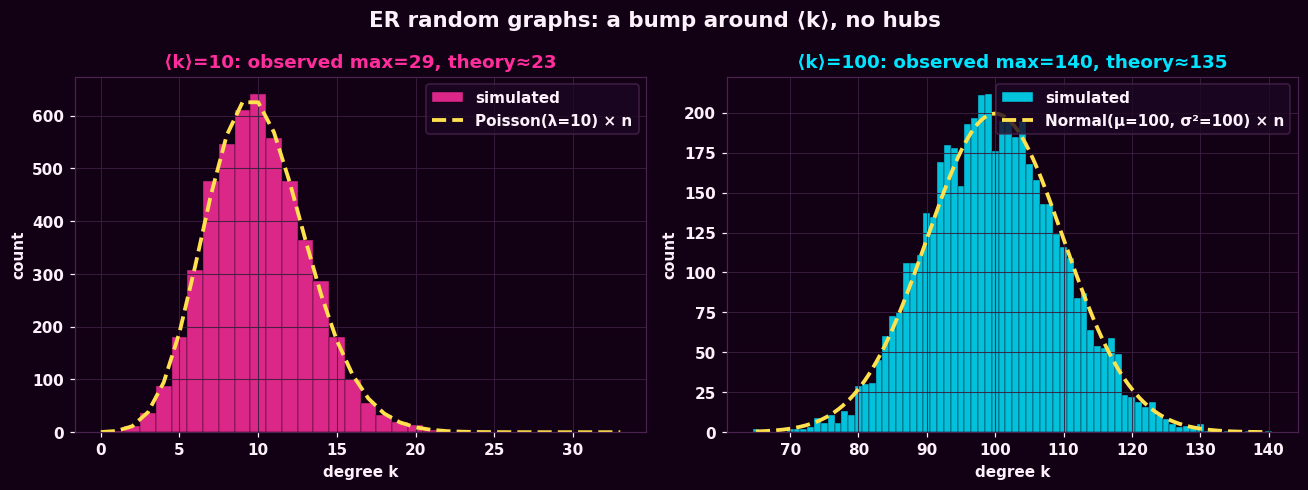

In [4]:
def theoretical_max_degree(n, dist):
    """Degree k* where n * P(K >= k*) ~= 1 -- the point past which we don't expect to see anything."""
    return dist.isf(1 / n)


n_nodes = 5000
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("ER random graphs: a bump around ⟨k⟩, no hubs", fontsize=14, fontweight="bold", color=TEXT)

panel_specs = [(axes[0], 10, "poisson", HOTPINK), (axes[1], 100, "normal", CYAN)]

for ax, k_target, kind, color in panel_specs:
    p = k_target / (n_nodes - 1)
    G = nx.fast_gnp_random_graph(n_nodes, p, seed=RNG_SEED)
    degrees = np.array([d for _, d in G.degree()])

    bins = np.arange(degrees.min(), degrees.max() + 2) - 0.5
    ax.hist(degrees, bins=bins, color=color, alpha=0.85, edgecolor=BG, linewidth=0.3, label="simulated")

    if kind == "poisson":
        dist = stats.poisson(k_target)
        ks = np.arange(0, degrees.max() + 5)
        ax.plot(ks, dist.pmf(ks) * n_nodes, color=YELLOW, lw=2.5, ls="--", label=f"Poisson(λ={k_target}) × n")
    else:
        dist = stats.norm(k_target, np.sqrt(k_target))
        ks = np.linspace(degrees.min(), degrees.max(), 400)
        ax.plot(ks, dist.pdf(ks) * n_nodes, color=YELLOW, lw=2.5, ls="--",
                 label=f"Normal(μ={k_target}, σ²={k_target}) × n")

    theo_max = theoretical_max_degree(n_nodes, dist)
    ax.set_title(f"⟨k⟩={k_target}: observed max={degrees.max()}, theory≈{theo_max:.0f}", color=color)
    ax.set_xlabel("degree k")
    ax.set_ylabel("count")
    ax.legend()

plt.tight_layout()
plt.savefig("assets/img/fig_er_degree_dist.png", dpi=150)
plt.show()

#### 2.2.2 — The giant-component phase transition

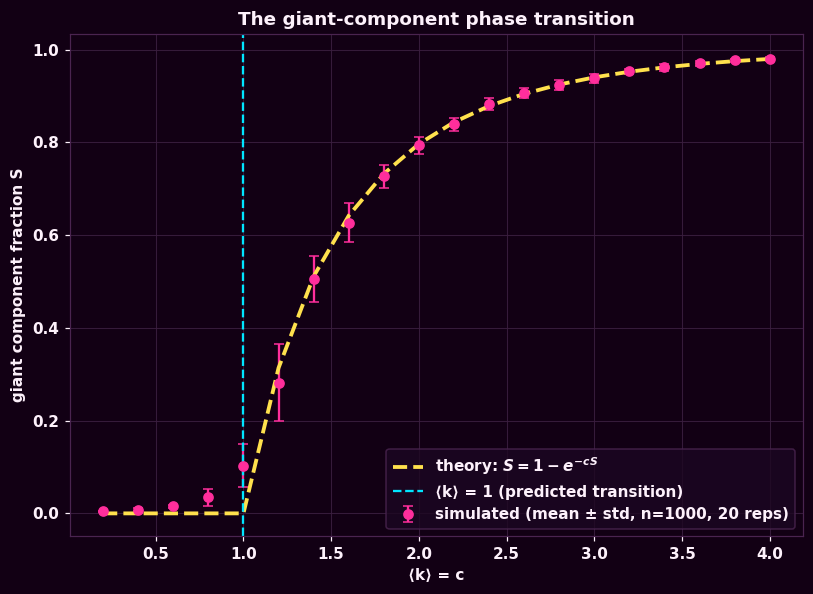

In [5]:
def giant_component_fraction(n, p, seed):
    G = nx.fast_gnp_random_graph(n, p, seed=seed)
    largest = max(len(c) for c in nx.connected_components(G))
    return largest / n


def theoretical_giant_fraction(c):
    """Solve S = 1 - exp(-c*S) by fixed-point iteration; S=0 is the only root for c<=1."""
    if c <= 1:
        return 0.0
    S = 0.999
    for _ in range(200):
        S = 1 - np.exp(-c * S)
    return S


n_nodes = 1000
n_reps = 20
c_values = np.linspace(0.2, 4.0, 20)
rng = np.random.default_rng(RNG_SEED)

means, stds = [], []
for c in c_values:
    p = c / (n_nodes - 1)
    fracs = [giant_component_fraction(n_nodes, p, int(rng.integers(1e9))) for _ in range(n_reps)]
    means.append(np.mean(fracs))
    stds.append(np.std(fracs))

theory = [theoretical_giant_fraction(c) for c in c_values]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.errorbar(c_values, means, yerr=stds, fmt="o", color=HOTPINK, ecolor=HOTPINK, capsize=3, markersize=6,
            label=f"simulated (mean ± std, n={n_nodes}, {n_reps} reps)")
ax.plot(c_values, theory, color=YELLOW, lw=2.5, ls="--", label=r"theory: $S = 1 - e^{-cS}$")
ax.axvline(1, color=CYAN, ls="--", lw=1.5, label="⟨k⟩ = 1 (predicted transition)")
ax.set_title("The giant-component phase transition", color=TEXT)
ax.set_xlabel("⟨k⟩ = c")
ax.set_ylabel("giant component fraction S")
ax.legend()
plt.tight_layout()
plt.savefig("assets/img/fig_giant_component_transition.png", dpi=150)
plt.show()

#### 2.2.3 — A network near the transition (n=200, ⟨k⟩=1.5)

n=200, ⟨k⟩=1.5: giant component has 109 nodes (54.5%), 59 components total


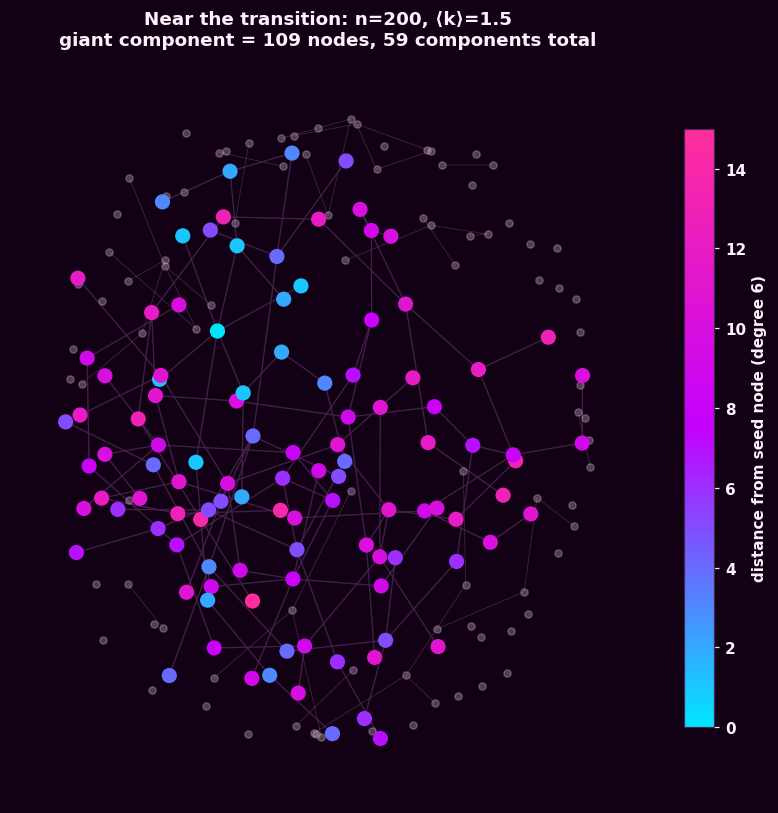

In [6]:
n_nodes, k_mean = 200, 1.5
p = k_mean / (n_nodes - 1)
G = nx.fast_gnp_random_graph(n_nodes, p, seed=RNG_SEED)

components_223 = sorted(nx.connected_components(G), key=len, reverse=True)
giant = G.subgraph(components_223[0]).copy()
print(
    f"n={n_nodes}, ⟨k⟩={k_mean}: giant component has {giant.number_of_nodes()} nodes "
    f"({100 * giant.number_of_nodes() / n_nodes:.1f}%), {len(components_223)} components total"
)

seed_node = max(giant.degree(), key=lambda x: x[1])[0]
dist_from_seed = nx.single_source_shortest_path_length(giant, seed_node)

pos = nx.spring_layout(G, seed=RNG_SEED, k=0.3)
fig, ax = plt.subplots(figsize=(7.5, 7.5))

non_giant_nodes = [v for v in G.nodes() if v not in giant]
non_giant_edges = [e for e in G.edges() if e[0] not in giant or e[1] not in giant]
nx.draw_networkx_nodes(G, pos, nodelist=non_giant_nodes, node_size=22, node_color=TEXT_DIM, alpha=0.35, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=non_giant_edges, edge_color=TEXT_DIM, width=0.5, alpha=0.25, ax=ax)

nodelist = list(giant.nodes())
colors = [dist_from_seed[v] for v in nodelist]
nx.draw_networkx_edges(giant, pos, edge_color=BORDER, width=0.9, alpha=0.85, ax=ax)
drawn = nx.draw_networkx_nodes(giant, pos, nodelist=nodelist, node_size=80, node_color=colors,
                                cmap=CYAN_MAGENTA, ax=ax)
cbar = plt.colorbar(drawn, ax=ax, label=f"distance from seed node (degree {giant.degree(seed_node)})", shrink=0.8)
cbar.ax.yaxis.label.set_color(TEXT)
cbar.ax.tick_params(colors=TEXT)

ax.set_title(
    f"Near the transition: n={n_nodes}, ⟨k⟩={k_mean}\n"
    f"giant component = {giant.number_of_nodes()} nodes, {len(components_223)} components total",
    color=TEXT,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("assets/img/fig_near_transition_viz.png", dpi=150)
plt.show()

#### 2.2.4 — A random network matching Marvel's n and m

Builds `comparison_table`, a running DataFrame comparing the real Marvel network to matched random networks. Later exercises (2.3.5 adds a clustering row, 2.8 adds configuration-model / edge-swap nulls) extend this same table rather than starting over.

In [7]:
def network_stats(G, label):
    n = G.number_of_nodes()
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    gc = G.subgraph(comps[0])
    degrees = [d for _, d in G.degree()]
    return {
        "network": label,
        "n": n,
        "m": G.number_of_edges(),
        "avg_k": 2 * G.number_of_edges() / n,
        "giant_component_frac": gc.number_of_nodes() / n,
        "n_components": len(comps),
        "n_isolates": sum(1 for d in degrees if d == 0),
        "max_degree": max(degrees),
        "avg_distance_gc": nx.average_shortest_path_length(gc),
    }


G_random_matched = nx.gnm_random_graph(n_marvel, m_marvel, seed=RNG_SEED)

comparison_table = pd.DataFrame(
    [
        network_stats(G_marvel, "Marvel (real)"),
        network_stats(G_random_matched, "Random G(n,m) matched"),
    ]
).set_index("network")
comparison_table

,n,m,avg_k,giant_component_frac,n_components,n_isolates,max_degree,avg_distance_gc
network,,,,,,,,
Marvel (real),303,1434,9.465347,0.914191,19,17,106,2.674332
"Random G(n,m) matched",303,1434,9.465347,1.000000,1,0,21,2.770988
